<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/OVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Multiklassen-Klassifikation mit logistischer Regression

In vorherigen Praktika haben wir uns mit binärer Klassifikation beschäftigt, z. B. zur Vorhersage von Ja/Nein-Entscheidungen. In dieser Einheit erweitern wir den Anwendungsbereich: **Wir wollen mehr als zwei Klassen unterscheiden**.

Ein typisches Beispiel ist die Klassifikation von handgeschriebenen Ziffern (0 bis 9), wie sie z. B. auf Formularen, Schecks oder Zählern vorkommen.

Wir verwenden dafür den bekannten `digits`-Datensatz aus `scikit-learn` und wenden eine **logistische Regression für mehrere Klassen** an. Dabei setzen wir den `OneVsRestClassifier` ein, um das Problem auf mehrere binäre Klassifikationsaufgaben zu zerlegen.

Am Ende lernen Sie:
- wie man einen Multiklassen-Klassifikator mit `scikit-learn` aufbaut,
- wie das `One-vs-Rest`-Prinzip funktioniert,
- wie man Vorhersagegüte mit einem `classification_report` und einer `confusion_matrix` bewertet.


Wir starten noch einmal mit der **binären Klassifikation** anhand eines sythetisch erzeugten Datensatzes.

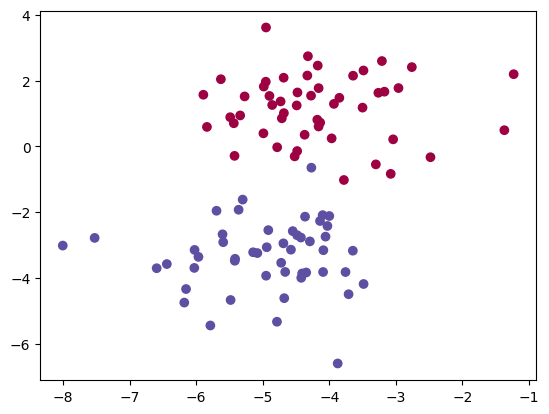

In [10]:
from sklearn.datasets import make_blobs #ist ein Werkzeug, das automatisch Punktwolken ("Blobs") erzeugt
import numpy as np
import matplotlib.pyplot as plt


# generating two-class dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2, center_box = (-5, 5)) # erzeuge 100 punkte, centers = suche dir 2 mittelpunkte aus (2 Klassen), nfeatures = jeder punkt hat  2 eigenschaften (x und y -koordinate)
#center_box=(-5, 5) → die Mittelpunkte der Wolken liegen irgendwo im Bereich von -5 bis +5
# X = enthält die koordinaten für jeden punkt / y = enthält die antworten, also Rot = 1 und Blau = 0
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral) # X[:, 0] = nimm aus allen zeilen : die erste spalte 0, also alle x - koordianten , X[:, 1] = " also alle y-koordianten
plt.show()

**Aufgabe:** Wenden Sie nun die bekannten Schritte an, um eine Klassifikation mit Logistischer Regression durchzuführen. Da wir synthetisch erzeugte Daten werwenden, können wir auf die Vorverarbeitungsschritte verzichten.

**(a)** Teilen Sie den Datensatz auf (70% Training, 30% Test):
- `X_train`: training dataset
- `X_test`: test dataset
- `y_train`: training labels
- `y_test`: test labels

In [11]:
from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = [None]*4
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)



In [12]:
# Test Cell
#----------

assert np.vstack((X_train, X_test)) in X and np.hstack((y_train, y_test)) in y
assert y_train.size/y.size == 0.7

**(b)** Verwenden Sie die *sklearn*-Klasse `LogisticRegression` um ein Modell für den Datensatz zu bilden. Trainieren Sie das Modell mit den oben festgelegten Trainingsdaten.

In [17]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train,y_train)



In [18]:
# Test Cell
#----------

assert type(logreg) == LogisticRegression
assert logreg.intercept_, 'Trainieren Sie das Modell mit den Daten!'

Wir visualisieren nun den Datensatz um darzustellen, wie gut unser Modell klassifiziert:

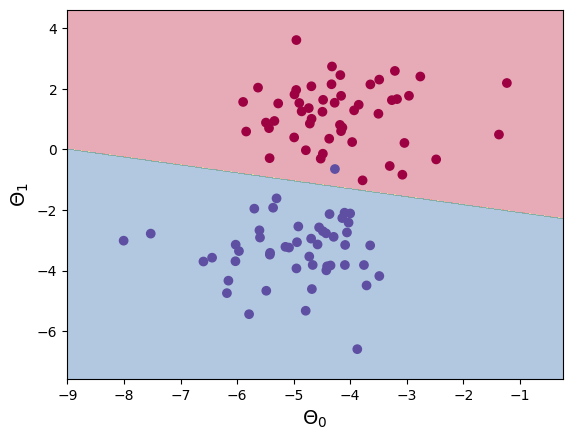

In [19]:
# Plotting decision regions
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 #größte x wert und kleinste
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1 #größte y wert und kleinste
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))

Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Spectral)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
plt.xlabel(r"$\Theta_0$", fontsize=14)
plt.ylabel(r"$\Theta_1$", fontsize=14)
plt.show()





---


**Schicht 1: Die Punkte**

Das sind die echten Datenpunkte aus deinem Datensatz:

🔴 Rote Punkte = Klasse 0

🔵 Blaue Punkte = Klasse 1

Die liegen genau dort, wo make_blobs sie erzeugt hat. Das sind die wahren Antworten.



---


**Schicht 2: Die farbigen Flächen**

Das sind die Vermutungen des Modells für das ganze Bild:

🌸 Rote Fläche = "Hier würde ich Klasse 0 (rot) vorhersagen"

🟦 Blaue Fläche = "Hier würde ich Klasse 1 (blau) vorhersagen"

Wenn hier ein neuer Punkt wäre — was würdest du sagen?" — und zwar für jeden einzelnen Punkt im Bild.

*Die linie dazwischen ist die Entscheidungsgrenze*


---



**(c)** Testen Sie die Vorhersagegenauigkeit (*accuracy*) des Modells mit den Testdaten:

In [23]:
y_pred = logreg.predict(X_test)
acc_test = logreg.score(X_test, y_test) * 100


print("accuracy: %.2f%%" % acc_test)

accuracy: 100.00%


In [24]:
# Test Cell
#----------

assert y_pred.shape == y_test.shape
### BEGIN HIDDEN TEST
assert acc_test == 100-np.sum(np.abs(y_pred-y_test))*100/len(y_pred)
### END HIDDEN TEST

### Multiklassen-Klassifikation

Die logistische Regression liefert uns Ergebnisse für binäre Zielvariablen.
Oftmals wollen wir aber mehr als 2 Klassen unterscheiden.

Eine Möglichkeit, um Multiklassen-Klassifikation mit logistischen Regression umzusetzen, ist die sogenannte *One-vs-all Klassifikation*.
Dabei werden für `n` Klassen `n` separate, binäre Klassifikationsprobleme definiert, bei denen jeweils nur die betrachtete Klasse den Zielwert `1` zugeteilt bekommt, und für alle anderen Klassen der Zielwert `0` angenommen wird.

**Hinweis:** Die Option `multi_class="ovr"` in `LogisticRegression` ist in neueren scikit-learn-Versionen veraltet. Stattdessen sollte der `OneVsRestClassifier` verwendet werden. Dieser Wrapper erzeugt automatisch ein separates binäres Klassifikationsmodell für jede Klasse (One-vs-Rest).

Mehr Infos: [scikit-learn: OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html)


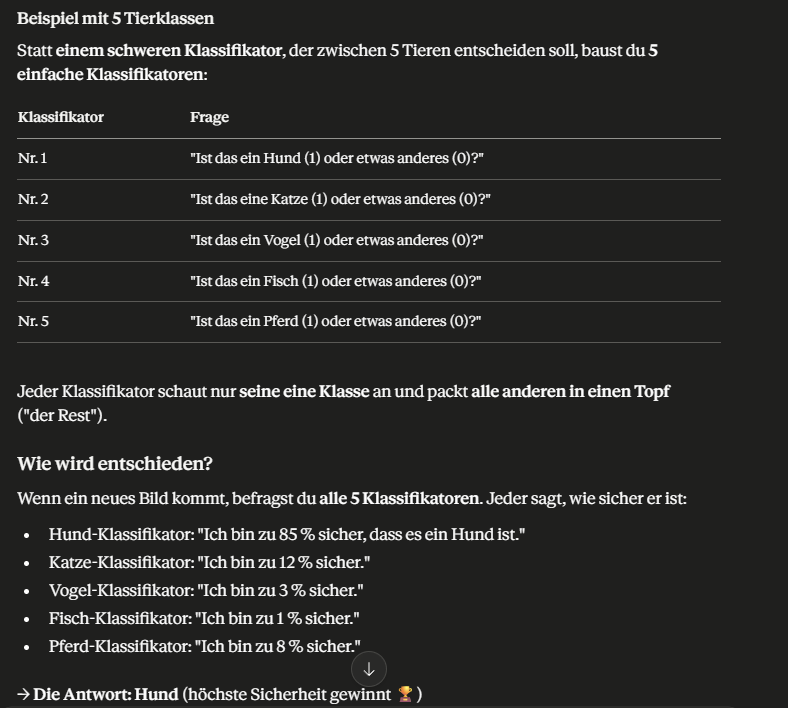

In [26]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

model = OneVsRestClassifier(LogisticRegression(solver='lbfgs')) # Der Solver ist der Algorithmus, der diese beste Linie sucht.
model.fit(X_train, y_train) #lernt



OneVsRestClassifier(estimator=LogisticRegression())

In der folgenden Code-Zelle erzeugen wir 3 Punktwolken.
Alle Punkte einer "Wolke" sollen zu einer bestimmten Klasse gehören.

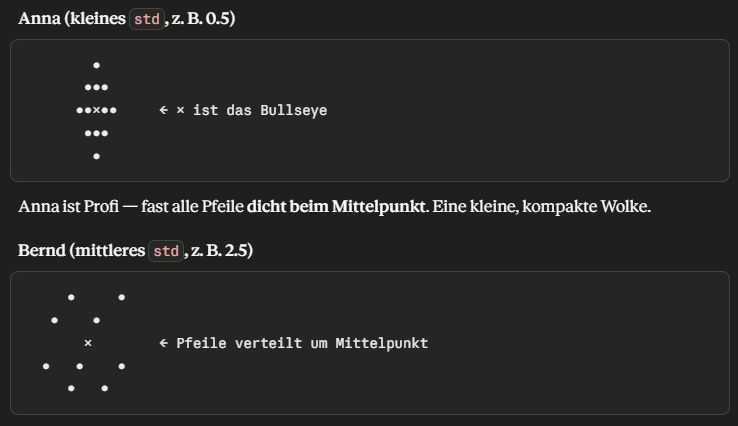

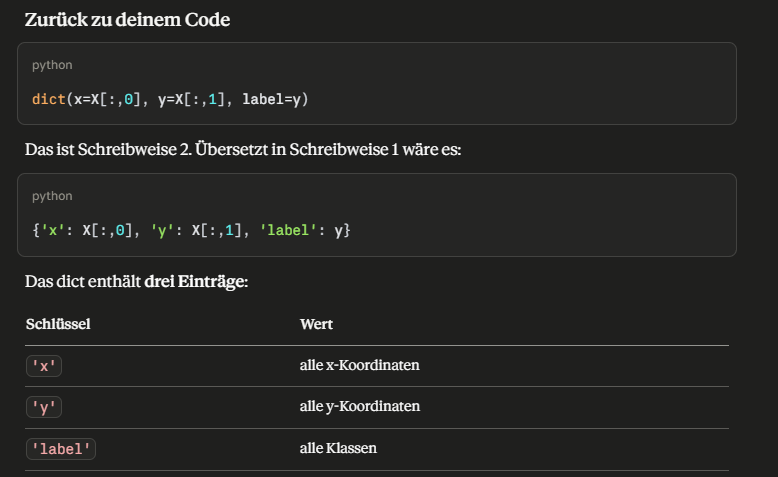

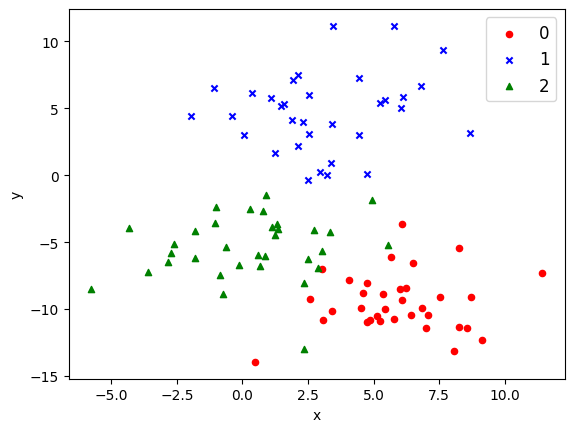

In [27]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from pandas import DataFrame
# generate 2d classification dataset
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=10, cluster_std=2.5) #3 klassen und bild

# scatter plot, dots colored by class value
df = DataFrame(dict(x=X[:,0], y=X[:,1], label=y)) #bild
colors = {0:'red', 1:'blue', 2:'green'}
markers = {0:'o', 1:'x', 2:'^'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, marker=markers[key], color=colors[key])

plt.legend(loc='upper right', prop={'size': 12})
plt.savefig("LogistischeRegression20.png",transparent=True, dpi=300)
plt.show()

Nun wenden wir ein logistisches Regressionsmodell auf die Datenbasis an.

In [29]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=0)# zerlegen 30%Testdaten

from sklearn.multiclass import OneVsRestClassifier
model = OneVsRestClassifier(LogisticRegression(solver='lbfgs')) #Der Wrapper, der die Bauanleitung mehrfach anwendet

model.fit(X_train,y_train) #lernt

#───────────────────────────────────────┐
#│ Klassifikator 1: "Ist es Klasse 0?"   │
#│   → trennt rote Kreise vom Rest       │
#├───────────────────────────────────────┤
#│ Klassifikator 2: "Ist es Klasse 1?"   │
#│   → trennt blaue Kreuze vom Rest      │
#├───────────────────────────────────────┤
#│ Klassifikator 3: "Ist es Klasse 2?"   │
#│   → trennt grüne Dreiecke vom Rest    │
#└───────────────────────────────────────┘'


OneVsRestClassifier(estimator=LogisticRegression())

Der folgende Graph zeigt die Entscheidungsgrenzen für das Klassifikationsmodell.
Alle Punkte innerhalb eines Bereiches werden der jeweiligen Klasse zugeordnet.

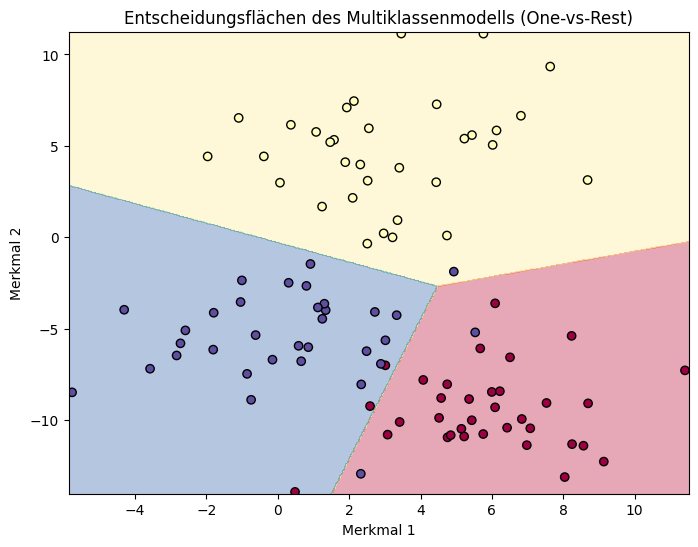

In [30]:
# Gitter erzeugen (für Fläche)
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Vorhersage für jeden Gitterpunkt
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) #Das Modell wird für jeden der 250 000 Punkte gefragt: "Klasse 0, 1 oder 2?". Die Antworten landen in Z.
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Spectral)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Spectral)
plt.xlabel("Merkmal 1")
plt.ylabel("Merkmal 2")
plt.title("Entscheidungsflächen des Multiklassenmodells (One-vs-Rest)")
plt.show()

## Fazit und Ausblick

In dieser Übung haben Sie gelernt, wie man **logistische Regression für mehr als zwei Klassen** verwendet. Die `scikit-learn`-Klasse `OneVsRestClassifier` macht dies besonders einfach, indem sie mehrere binäre Klassifikatoren trainiert.

Ein realistisches Beispiel für den Einsatz ist die Erkennung handschriftlicher Ziffern. Die Klassifikation erfolgt auf Grundlage von 64 Merkmalen (8x8 Pixelbilder). Durch Vorverarbeitung (z. B. Standardisierung) und Auswahl geeigneter Modelle kann die Genauigkeit auf über 95 % gesteigert werden.

Im nächsten Schritt lernen Sie:
- wie neuronale Netze (z. B. MLP oder CNN) Multiklassen-Probleme lösen,
- wie man Präzision, Recall und F1-Score im Detail interpretiert,
- und wie man Modelle über Kreuzvalidierung robuster bewertet.
